# 真的需要看全部历史吗？滑动窗口注意力

03 章我们用 GQA 把 KV cache 砍小了。但还有个更根本的问题：哪怕用了 GQA，KV cache 仍会
**随上下文长度线性增长**——上下文 100 万 token，缓存还是会爆。

这一章换个角度发问：第 100 万个 token，真的需要回头看前面 99 万个吗？语言有很强的**局部性**，
答案往往是"不必"。**滑动窗口注意力**就把每个 token 的视野限制在最近 $W$ 个 token 内。

有意思的是——03 那个从 vLLM 提取的 kernel **本就自带**滑窗能力，这一章我们不写新 kernel，
只是把它点亮。


In [1]:
import sys, math
from pathlib import Path

import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "04-sliding-window"))

from common import naive_attention, make_qkv, bench_ms
from sliding import sliding_window_attention
sys.path.insert(0, str(ROOT / "03-gqa-mqa"))
from gqa import gqa_attention   # 用作 full-causal 对照

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0), "| 本章复用 03 的 kernel（自带滑窗）")


跑在 NVIDIA GeForce RTX 4090 | 本章复用 03 的 kernel（自带滑窗）


## 窗口掩码长什么样

滑窗在数学上很简单：在因果掩码（只看过去）之外，再屏蔽掉"太老"的 key——
query $i$ 只保留 key $\in (i-W,\ i]$。把两种掩码并排画出来（蓝色=可见）：


/tmp/ipykernel_1826317/628096784.py:12: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/628096784.py:12: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/628096784.py:12: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/628096784.py:12: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/628096784.py:12: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/628096784.py:12: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipyke

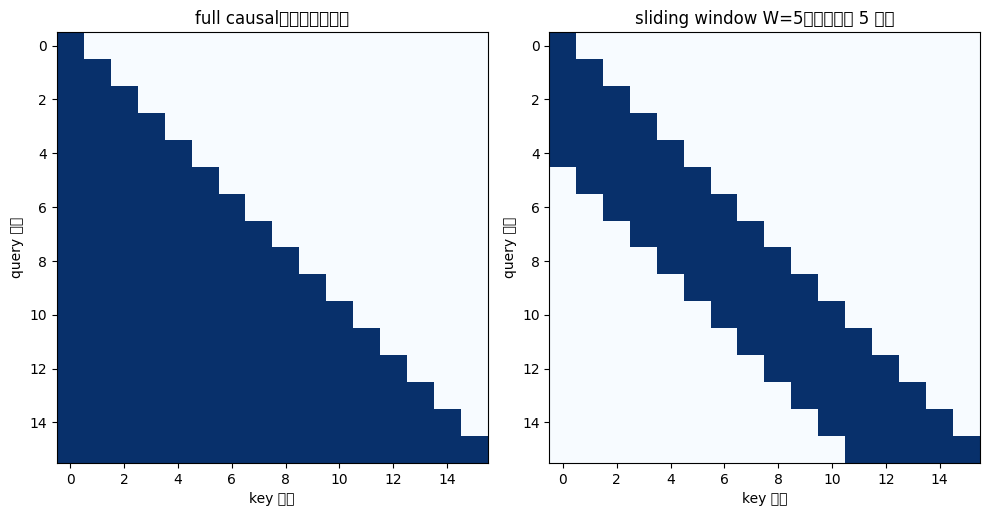

右图每行只剩一条宽 W 的对角带——更早的历史被挡在窗口外。


In [2]:
S, W = 16, 5
qi = torch.arange(S)[:, None]
ki = torch.arange(S)[None, :]
full_mask = (ki <= qi).float()
sw_mask = ((ki <= qi) & (ki > qi - W)).float()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, m, t in [(axes[0], full_mask, "full causal（看全部过去）"),
                 (axes[1], sw_mask, f"sliding window W={W}（只看最近 {W} 个）")]:
    ax.imshow(m, cmap="Blues", vmin=0, vmax=1)
    ax.set(title=t, xlabel="key 位置", ylabel="query 位置")
plt.tight_layout(); plt.show()
print("右图每行只剩一条宽 W 的对角带——更早的历史被挡在窗口外。")


## 点亮 kernel：一个需要小心的 off-by-one

03 的 kernel 用参数 `SLIDING_WINDOW` 表示"key 不得早于 query 之前这么多个位置"，
它实际允许 `SLIDING_WINDOW + 1` 个位置。所以"看最近 $W$ 个 token"要传 `W - 1`。
`sliding.py` 已替我们换算好了，直接给 `window_size` 即可。我们和朴素带窗参考对一对：


In [3]:
q, k, v = make_qkv(2, 8, 512, 64, dtype=torch.float16, seed=0)
for W in [32, 64, 128]:
    out = sliding_window_attention(q, k, v, window_size=W, causal=True)
    ref = naive_attention(q, k, v, causal=True, window=W)   # common 的带窗参考
    err = (out.float() - ref.float()).abs().max().item()
    print(f"window_size={W:>3}（kernel 内部传 SLIDING_WINDOW={W-1:>3}）: 最大差异 {err:.1e}  ✓")
print("\n换算正确，滑窗和朴素参考严格一致。")


window_size= 32（kernel 内部传 SLIDING_WINDOW= 31）: 最大差异 2.0e-03  ✓
window_size= 64（kernel 内部传 SLIDING_WINDOW= 63）: 最大差异 2.0e-03  ✓
window_size=128（kernel 内部传 SLIDING_WINDOW=127）: 最大差异 2.0e-03  ✓

换算正确，滑窗和朴素参考严格一致。


## 滑窗真正的价值：decode 时 KV cache 被「钉死」

为什么要费劲做滑窗？关键在**推理 decode**。既然每个新 token 只看最近 $W$ 个，那更早的 K/V
**永远不会再被用到，可以直接丢弃**。于是 KV cache **固定为 $W$，不再随上下文增长**。

把 full 和滑窗的 KV cache 随上下文长度画出来（注意纵轴是对数）：


/tmp/ipykernel_1826317/644314032.py:13: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/644314032.py:13: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/644314032.py:13: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/644314032.py:13: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/644314032.py:13: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1826317/644314032.py:13: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipyke

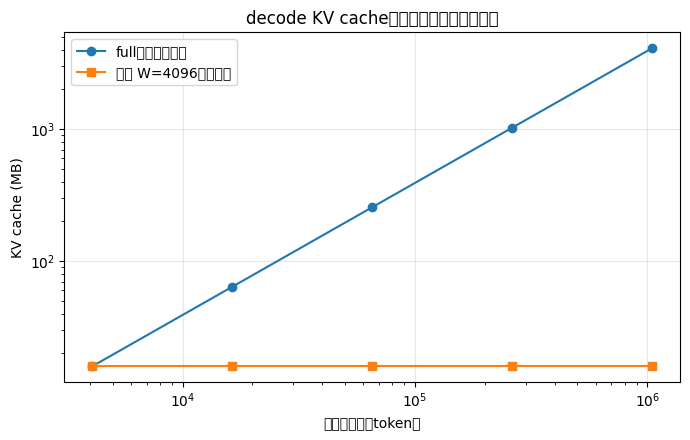

上下文 100 万 token 时：full 需 4096MB，滑窗只要 16MB（省 256×）。


In [4]:
window = 4096
ctxs = [4096, 16384, 65536, 262144, 1048576]
Hkv, D = 8, 128
full = [2 * Hkv * c * D * 2 / 1024**2 for c in ctxs]
sw   = [2 * Hkv * min(c, window) * D * 2 / 1024**2 for c in ctxs]

plt.figure(figsize=(7, 4.5))
plt.plot(ctxs, full, "o-", label="full（线性增长）")
plt.plot(ctxs, sw, "s-", label=f"滑窗 W={window}（固定）")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("上下文长度（token）"); plt.ylabel("KV cache (MB)")
plt.title("decode KV cache：滑窗被钉死在窗口大小"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"上下文 100 万 token 时：full 需 {full[-1]:.0f}MB，滑窗只要 {sw[-1]:.0f}MB（省 {full[-1]/sw[-1]:.0f}×）。")


## 诚实一点：这个实现**不**加速 prefill

容易误以为"窗口小了，计算就少了"。但本章 kernel 是用**掩码**实现滑窗的——窗口外的 key 块
照样被读进来算、再屏蔽掉，循环范围并没有缩小。所以 prefill 延迟和 full causal 几乎一样：


In [5]:
print(f"{'seqlen':>8} {'full ms':>10} {'滑窗 ms':>10}")
for S in [4096, 8192]:
    q, k, v = make_qkv(2, 8, S, 128, kv_heads=2, dtype=torch.float16, seed=0)
    ms_full = bench_ms(lambda: gqa_attention(q, k, v, causal=True))
    ms_sw = bench_ms(lambda: sliding_window_attention(q, k, v, window_size=4096, causal=True))
    print(f"{S:>8} {ms_full:>8.3f} {ms_sw:>9.3f}")
    del q, k, v; torch.cuda.empty_cache()
print("\n二者相近——滑窗省的是 decode 的 KV cache，不是 prefill 的算力。")
print("要在 prefill 也省，需让 kernel 主动跳过窗口外的整块（block-sparse），那是后面稀疏注意力的主题。")


  seqlen    full ms      滑窗 ms


    4096    0.765     0.768


    8192    2.413     2.594

二者相近——滑窗省的是 decode 的 KV cache，不是 prefill 的算力。
要在 prefill 也省，需让 kernel 主动跳过窗口外的整块（block-sparse），那是后面稀疏注意力的主题。


## 收尾

- 滑动窗口让每个 token 只看最近 $W$ 个，背后是语言的**局部性**；多层堆叠后感受野会线性放大；
- 实现就是在因果掩码上再加一道窗口掩码（注意 `window_size` 与 kernel `SLIDING_WINDOW` 差 1）；
- **真正的价值在 decode**：KV cache 固定为 $W$、不随上下文增长，是长上下文的关键；
- 本章的掩码实现**不加速 prefill**——想省 prefill 算力得 block-sparse 地跳块，这就引出了稀疏注意力。

**下一站** → `05-paged-attention`：推理时这些 KV cache 在显存里到底怎么摆放、怎么管理？
